In [1]:

import zipfile, os

zip_path = "/workspace/dataset-original.zip"
extract_path = "/home/jovyan/trash-datavol-2/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)



Extracted to: /home/jovyan/trash-datavol-2/dataset


In [2]:
import os

dataset_root = "/home/jovyan/trash-datavol-2/dataset"
print("Contents of dataset folder:", os.listdir(dataset_root))


Contents of dataset folder: ['__MACOSX', 'dataset-original', 'split-dataset']


In [3]:
import os
from collections import Counter

# Correct TrashNet dataset root
data_dir = "/home/jovyan/trash-datavol-2/dataset/dataset-original"

# Collect all image paths
image_paths = []
for root, dirs, files in os.walk(data_dir):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, f))

# Dataset info
total_images = len(image_paths)
class_counts = Counter([os.path.basename(os.path.dirname(p)) for p in image_paths])

print("🗑️ TrashNet Dataset Summary")
print("-" * 40)
print(f"Root folder: {data_dir}")
print(f"Total images: {total_images}")
print(f"Number of classes: {len(class_counts)}")
print("Classes:", list(class_counts.keys()))
print("\nImage count per class:")
for cls, count in class_counts.items():
    print(f"  {cls:10s} : {count}")

print("\n🔍 Example file paths:")
for p in image_paths[:5]:
    print(" ", p)


🗑️ TrashNet Dataset Summary
----------------------------------------
Root folder: /home/jovyan/trash-datavol-2/dataset/dataset-original
Total images: 2527
Number of classes: 6
Classes: ['glass', 'plastic', 'metal', 'cardboard', 'paper', 'trash']

Image count per class:
  glass      : 501
  plastic    : 482
  metal      : 410
  cardboard  : 403
  paper      : 594
  trash      : 137

🔍 Example file paths:
  /home/jovyan/trash-datavol-2/dataset/dataset-original/glass/glass70.jpg
  /home/jovyan/trash-datavol-2/dataset/dataset-original/glass/glass21.jpg
  /home/jovyan/trash-datavol-2/dataset/dataset-original/glass/glass422.jpg
  /home/jovyan/trash-datavol-2/dataset/dataset-original/glass/glass79.jpg
  /home/jovyan/trash-datavol-2/dataset/dataset-original/glass/glass83.jpg


🖼️ Total images checked: 2527
Unique sizes: 2
Most common size: (4032, 3024)
Image modes: {'RGB'}
Corrupt files: 0


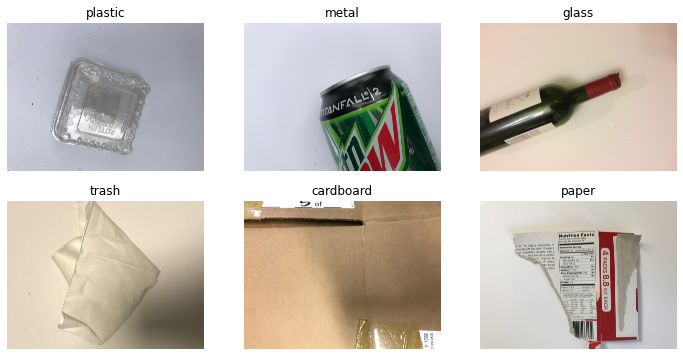

In [4]:
from PIL import Image
import os
import numpy as np
import random
import matplotlib.pyplot as plt

data_dir = "/home/jovyan/trash-datavol-2/dataset/dataset-original"

# Collect all image paths
image_paths = []
for root, dirs, files in os.walk(data_dir):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, f))

# Check image sizes & modes
sizes = []
modes = []
corrupt_files = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            sizes.append(img.size)  # (width, height)
            modes.append(img.mode)  # e.g., 'RGB', 'L'
    except Exception as e:
        corrupt_files.append(path)

print("🖼️ Total images checked:", len(image_paths))
print("Unique sizes:", len(set(sizes)))
print("Most common size:", max(set(sizes), key=sizes.count))
print("Image modes:", set(modes))
print("Corrupt files:", len(corrupt_files))

# Show random samples
sample_paths = random.sample(image_paths, 6)
plt.figure(figsize=(12, 6))
for i, path in enumerate(sample_paths):
    img = Image.open(path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(path)))
    plt.axis("off")
plt.show()


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split
from collections import Counter

# Paths
DATASET_ROOT = "/home/jovyan/trash-datavol-2/dataset/dataset-original"
OUTPUT_ROOT = "/home/jovyan/trash-datavol-2/dataset/split-dataset"

# Split ratios
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# Safety: create dirs
def make_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def stratified_split(class_name, files):
    """Split one class into train/val/test sets"""
    train_files, temp_files = train_test_split(
        files, train_size=TRAIN_RATIO, stratify=None, random_state=42
    )
    val_files, test_files = train_test_split(
        temp_files, test_size=0.5, stratify=None, random_state=42
    )
    return train_files, val_files, test_files

# Main loop
summary = {}

for class_name in os.listdir(DATASET_ROOT):
    class_dir = os.path.join(DATASET_ROOT, class_name)
    if not os.path.isdir(class_dir):
        continue
    
    files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    train_files, val_files, test_files = stratified_split(class_name, files)
    summary[class_name] = {
        "train": len(train_files),
        "val": len(val_files),
        "test": len(test_files),
        "total": len(files)
    }
    
    # Copy files
    for split_name, split_files in zip(["train", "val", "test"], [train_files, val_files, test_files]):
        split_dir = os.path.join(OUTPUT_ROOT, split_name, class_name)
        make_dir(split_dir)
        for f in split_files:
            shutil.copy2(f, split_dir)

# Print summary
print("\n📊 Dataset split summary:")
total_all = 0
for cls, counts in summary.items():
    print(f" {cls:<10} → Train: {counts['train']:3d}, Val: {counts['val']:3d}, Test: {counts['test']:3d}, Total: {counts['total']}")
    total_all += counts['total']

print(f"\n✅ Done! Total images processed: {total_all}")
print(f"📂 New dataset root: {OUTPUT_ROOT}")



📊 Dataset split summary:
 glass      → Train: 400, Val:  50, Test:  51, Total: 501
 plastic    → Train: 385, Val:  48, Test:  49, Total: 482
 metal      → Train: 328, Val:  41, Test:  41, Total: 410
 cardboard  → Train: 322, Val:  40, Test:  41, Total: 403
 paper      → Train: 475, Val:  59, Test:  60, Total: 594
 trash      → Train: 109, Val:  14, Test:  14, Total: 137

✅ Done! Total images processed: 2527
📂 New dataset root: /home/jovyan/trash-datavol-2/dataset/split-dataset


In [6]:
import torch, torchvision
print(torch.__version__)
print(torchvision.__version__)

2.4.1+cu118
0.19.1+cu118


In [7]:
# Cell 1 — Imports & config
import os, copy, random, time
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import pandas as pd

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True  # speed on fixed input sizes

# Paths (use your split made earlier)
DATASET_SPLIT = "/home/jovyan/trash-datavol-2/dataset/split-dataset"

# Classes (TrashNet)
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"CUDA available? {torch.cuda.is_available()}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available? True
Device: cuda
GPU: NVIDIA H100 80GB HBM3 MIG 1g.10gb


In [8]:
# Cell 2 — Dataset sanity checks (fast, avoids PIL I/O)
def summarize_split(split_root):
    counts = {}
    total = 0
    for cls in sorted(os.listdir(split_root)):
        cls_path = os.path.join(split_root, cls)
        if not os.path.isdir(cls_path): 
            continue
        n = len([f for f in os.listdir(cls_path) 
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        counts[cls] = n
        total += n
    return total, counts

for split in ["train", "val", "test"]:
    split_dir = os.path.join(DATASET_SPLIT, split)
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"Missing split: {split_dir}")
    total, counts = summarize_split(split_dir)
    print(f"\n[{split.upper()}] total={total}")
    for k in sorted(counts):
        print(f"  {k:10s}: {counts[k]}")

# quick guard: ensure only the 6 expected classes are present
for split in ["train","val","test"]:
    classes = sorted([d for d in os.listdir(os.path.join(DATASET_SPLIT,split)) if os.path.isdir(os.path.join(DATASET_SPLIT,split,d))])
    extra = set(classes) - set(CLASS_NAMES)
    missing = set(CLASS_NAMES) - set(classes)
    if extra:
        print(f"⚠️ Extra folders in {split}: {sorted(extra)} (will be ignored by ImageFolder only if empty)")
    if missing:
        raise RuntimeError(f"❌ Missing classes in {split}: {sorted(missing)}")



[TRAIN] total=2019
  cardboard : 322
  glass     : 400
  metal     : 328
  paper     : 475
  plastic   : 385
  trash     : 109

[VAL] total=252
  cardboard : 40
  glass     : 50
  metal     : 41
  paper     : 59
  plastic   : 48
  trash     : 14

[TEST] total=256
  cardboard : 41
  glass     : 51
  metal     : 41
  paper     : 60
  plastic   : 49
  trash     : 14


In [9]:
# Cell 3 — Transforms (CLAHE + stronger crops)

# CLAHE transform (keeps RGB)
class CLAHETransform:
    def __init__(self, clip=2.0, tile=8):
        self.clip = clip
        self.tile = tile
    def __call__(self, img):
        # img is PIL -> to numpy RGB
        img_np = np.array(img.convert("RGB"))
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=self.clip, tileGridSize=(self.tile, self.tile))
        cl = clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        out = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        return Image.fromarray(out)

# Train: encourage zoom-in (reduce background), color/geo jitter, then CLAHE
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.9, 1.1)),  # zoom in
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.02),
    CLAHETransform(clip=2.0, tile=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Val/Test: deterministic tighter crop + CLAHE
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),               # tighter than Resize->CenterCrop helps reduce bg
    CLAHETransform(clip=2.0, tile=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])



In [10]:
# Cell 4 — Datasets + Sampler + DataLoaders (fast I/O)

# ImageFolder datasets
image_datasets = {
    "train": datasets.ImageFolder(root=os.path.join(DATASET_SPLIT, "train"), transform=train_transform),
    "val":   datasets.ImageFolder(root=os.path.join(DATASET_SPLIT, "val"),   transform=eval_transform),
    "test":  datasets.ImageFolder(root=os.path.join(DATASET_SPLIT, "test"),  transform=eval_transform),
}

# sanity: ensure class order matches expectation (won't affect training, but we log it)
print("\nDetected classes (ImageFolder order):", image_datasets["train"].classes)

# Class counts from train targets
train_targets = np.array(image_datasets["train"].targets)
class_counts = np.bincount(train_targets, minlength=len(image_datasets["train"].classes))
print("Train class counts:", dict(zip(image_datasets["train"].classes, class_counts.tolist())))

# Weighted sampler (inverse freq)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[train_targets]
sampler = WeightedRandomSampler(weights=torch.as_tensor(sample_weights, dtype=torch.float),
                                num_samples=len(sample_weights),
                                replacement=True)

# DataLoaders — speed flags for H100
BATCH_SIZE = 32
NUM_WORKERS = 4  # bump if your storage keeps up
dataloaders = {
    "train": DataLoader(image_datasets["train"], batch_size=BATCH_SIZE, sampler=sampler,
                        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True),
    "val":   DataLoader(image_datasets["val"],   batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True),
    "test":  DataLoader(image_datasets["test"],  batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True),
}
dataset_sizes = {k: len(image_datasets[k]) for k in image_datasets}
print("Dataset sizes:", dataset_sizes)
NUM_CLASSES = len(image_datasets["train"].classes)



Detected classes (ImageFolder order): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train class counts: {'cardboard': 322, 'glass': 400, 'metal': 328, 'paper': 475, 'plastic': 385, 'trash': 109}
Dataset sizes: {'train': 2019, 'val': 252, 'test': 256}


In [11]:
# Cell 5 — Model factory + train/val/test (with AMP, class-weighted loss)

def create_model(name, num_classes):
    if name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    elif name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.last_channel, num_classes)
    else:
        raise ValueError(name)
    return m.to(device)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x,y in loader:
        x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
        logits = model(x)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / max(total,1)

def train_one_model(model_name, num_epochs=10, base_lr=1e-4):
    print(f"\n===== Training {model_name} =====")
    model = create_model(model_name, NUM_CLASSES)

    # Class-weighted cross-entropy (to complement the sampler)
    # Normalize weights for stability
    cw = torch.tensor(class_counts, dtype=torch.float32)
    cw = cw.mean() / torch.clamp(cw, min=1)   # inverse proportional
    criterion = nn.CrossEntropyLoss(weight=cw.to(device))

    optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    best_wts = copy.deepcopy(model.state_dict())
    best_val = 0.0

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, num_epochs+1):
        # ---- Train ----
        model.train()
        run_loss, run_correct, run_total = 0.0, 0, 0
        for xb, yb in tqdm(dataloaders["train"], desc=f"{model_name} | epoch {epoch}/{num_epochs} [train]", leave=False):
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                out = model(xb)
                loss = criterion(out, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            run_loss += loss.item() * xb.size(0)
            run_correct += (out.argmax(1) == yb).sum().item()
            run_total += yb.size(0)

        train_loss = run_loss / run_total
        train_acc  = run_correct / run_total

        # ---- Val ----
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in dataloaders["val"]:
                xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    out = model(xb)
                    loss = criterion(out, yb)
                v_loss += loss.item() * xb.size(0)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_total += yb.size(0)

        val_loss = v_loss / v_total
        val_acc  = v_correct / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d} | "
              f"Train: loss {train_loss:.4f}, acc {train_acc:.4f} | "
              f"Val: loss {val_loss:.4f}, acc {val_acc:.4f}")

        if val_acc > best_val:
            best_val = val_acc
            best_wts = copy.deepcopy(model.state_dict())

    # load best
    model.load_state_dict(best_wts)

    # ---- Test ----
    test_acc = evaluate(model, dataloaders["test"])
    print(f"✅ {model_name}: Best Val Acc={best_val:.4f} | Test Acc={test_acc:.4f}")

    return model, history, best_val, test_acc


In [12]:
def train_and_evaluate(model, train_loader, val_loader, test_loader, num_epochs=10, lr=0.001):
    num_classes = len(train_loader.dataset.classes)
    model = model.to(device)
    
    # Use class weights in loss
    class_counts = np.bincount(train_loader.dataset.targets)
    class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ---- Training ----
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc = running_corrects / total

        # ---- Validation ----
        model.eval()
        running_loss, running_corrects, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels).item()
                total += labels.size(0)

        epoch_val_loss = running_loss / total
        epoch_val_acc = running_corrects / total

        print(f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        # Save best model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    # Load best model
    model.load_state_dict(best_model_wts)

    # ---- Test Evaluation ----
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=test_loader.dataset.classes))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

    test_acc = sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
    print(f"✅ Test Accuracy: {test_acc:.4f}")

    return model, history, test_acc


In [13]:
import torch
print("CUDA available?", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA available? True
GPU count: 1
Device name: NVIDIA H100 80GB HBM3 MIG 1g.10gb


In [14]:
!pip install timm


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


Dataset info before training


In [15]:
# Cell 6 — Train 5 models & summarize
models_to_train = [
    "resnet18",
    "resnet50",
    "densenet121",
    "efficientnet_b0",
    "mobilenet_v2",
]

all_results = []
all_histories = {}

START_LR = 1e-4      # safe default for fine-tuning
EPOCHS   = 10        # bump if time allows

for mname in models_to_train:
    model, hist, best_val, test_acc = train_one_model(mname, num_epochs=EPOCHS, base_lr=START_LR)
    # save weights
    torch.save(model.state_dict(), f"{mname}_best.pth")
    all_histories[mname] = hist
    all_results.append([mname, best_val, test_acc])

df = pd.DataFrame(all_results, columns=["Model", "Best_Val_Acc", "Test_Acc"])
print("\n===== Final Results =====")
print(df)



===== Training resnet18 =====


/tmp/ipykernel_39888/649863302.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
resnet18 | epoch 1/10 [train]:   0%|          | 0/64 [00:00<?, ?it/s]/tmp/ipykernel_39888/649863302.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_39888/649863302.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01 | Train: loss 0.6492, acc 0.7162 | Val: loss 0.4549, acc 0.8175


Epoch 02 | Train: loss 0.2552, acc 0.9069 | Val: loss 0.3497, acc 0.8611


Epoch 03 | Train: loss 0.1541, acc 0.9376 | Val: loss 0.2989, acc 0.8889


...

Epoch 06 | Train: loss 0.1680, acc 0.9336 | Val: loss 0.3476, acc 0.8770


Epoch 07 | Train: loss 0.1391, acc 0.9500 | Val: loss 0.3342, acc 0.8730


Epoch 08 | Train: loss 0.0965, acc 0.9658 | Val: loss 0.3096, acc 0.9008


Epoch 09 | Train: loss 0.0953, acc 0.9614 | Val: loss 0.3427, acc 0.8770


Epoch 10 | Train: loss 0.0749, acc 0.9713 | Val: loss 0.2915, acc 0.9048
✅ mobilenet_v2: Best Val Acc=0.9048 | Test Acc=0.9570

===== Final Results =====
             Model  Best_Val_Acc  Test_Acc
0         resnet18      0.912698  0.937500
1         resnet50      0.928571  0.964844
2      densenet121      0.936508  0.941406
3  efficientnet_b0      0.916667  0.949219
4     mobilenet_v2      0.904762  0.957031


In [25]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model constructors
def build_model(name, num_classes):
    if name == "resnet18":
        model = models.resnet18(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "resnet50":
        model = models.resnet50(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = models.densenet121(pretrained=False)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif name == "mobilenet_v2":
        model = models.mobilenet_v2(pretrained=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model {name}")
    return model

# Your models
models_to_eval = [
    "resnet18",
    "resnet50",
    "densenet121",
    "efficientnet_b0",
    "mobilenet_v2",
]

num_classes = len(image_datasets["train"].classes)

results = []
all_reports = {}
all_conf_matrices = {}

for mname in models_to_eval:
    print(f"\n🔍 Evaluating {mname}...")

    # Recreate model
    model = build_model(mname, num_classes).to(device)

    # Load weights
    state_dict = torch.load(f"{mname}_best.pth", map_location=device)
    model.load_state_dict(state_dict)

    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Accuracy
    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean().item()

    # Classification report
    report = classification_report(
        y_true, y_pred, target_names=image_datasets["train"].classes, output_dict=True
    )
    conf_matrix = confusion_matrix(y_true, y_pred)

    results.append({"Model": mname, "Test Accuracy": acc})
    all_reports[mname] = report
    all_conf_matrices[mname] = conf_matrix

# Put results into a DataFrame
df_results = pd.DataFrame(results)
print("\n===== Test Accuracies =====")
print(df_results)

# If you want to save:
df_results.to_csv("test_results.csv", index=False)



🔍 Evaluating resnet18...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3174847149.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio


🔍 Evaluating resnet50...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3174847149.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio


🔍 Evaluating densenet121...


...


🔍 Evaluating efficientnet_b0...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3174847149.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio


🔍 Evaluating mobilenet_v2...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3174847149.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio


===== Test Accuracies =====
             Model  Test Accuracy
0         resnet18       0.937500
1         resnet50       0.964844
2      densenet121       0.941406
3  efficientnet_b0       0.949219
4     mobilenet_v2       0.957031


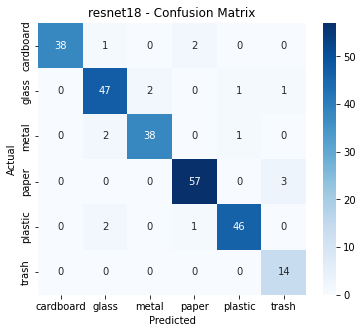

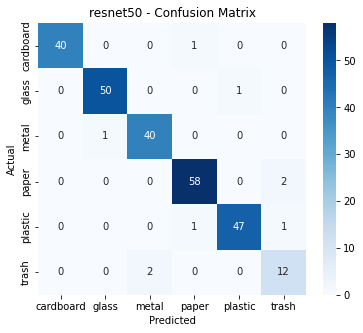

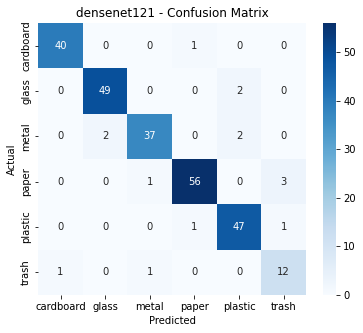

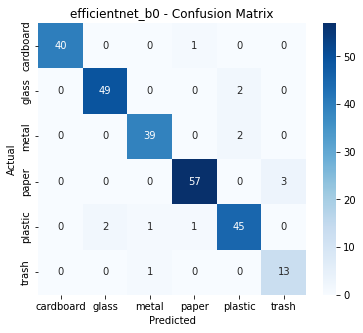

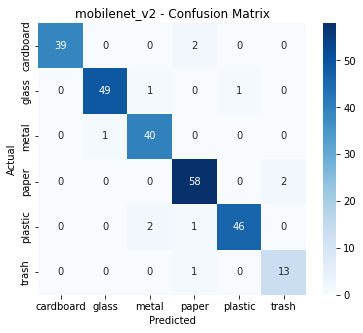

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

for mname, cm in all_conf_matrices.items():
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=image_datasets["train"].classes, 
                yticklabels=image_datasets["train"].classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{mname} - Confusion Matrix")
    plt.show()


In [30]:
for mname, report in all_reports.items():
    print(f"\n📊 Classification Report for {mname}")
    df_report = pd.DataFrame(report).transpose()
    display(df_report.round(3))



📊 Classification Report for resnet18


,precision,recall,f1-score,support
cardboard,1.000,0.927,0.962,41.000
glass,0.904,0.922,0.913,51.000
metal,0.950,0.927,0.938,41.000
paper,0.950,0.950,0.950,60.000
plastic,0.958,0.939,0.948,49.000
trash,0.778,1.000,0.875,14.000
accuracy,0.938,0.938,0.938,0.938
macro avg,0.923,0.944,0.931,256.000
weighted avg,0.941,0.938,0.938,256.000



📊 Classification Report for resnet50


,precision,recall,f1-score,support
cardboard,1.000,0.976,0.988,41.000
glass,0.980,0.980,0.980,51.000
metal,0.952,0.976,0.964,41.000
paper,0.967,0.967,0.967,60.000
plastic,0.979,0.959,0.969,49.000
trash,0.800,0.857,0.828,14.000
accuracy,0.965,0.965,0.965,0.965
macro avg,0.946,0.952,0.949,256.000
weighted avg,0.966,0.965,0.965,256.000



📊 Classification Report for densenet121


,precision,recall,f1-score,support
cardboard,0.976,0.976,0.976,41.000
glass,0.961,0.961,0.961,51.000
metal,0.949,0.902,0.925,41.000
paper,0.966,0.933,0.949,60.000
plastic,0.922,0.959,0.940,49.000
trash,0.750,0.857,0.800,14.000
accuracy,0.941,0.941,0.941,0.941
macro avg,0.920,0.931,0.925,256.000
weighted avg,0.943,0.941,0.942,256.000



📊 Classification Report for efficientnet_b0


,precision,recall,f1-score,support
cardboard,1.000,0.976,0.988,41.000
glass,0.961,0.961,0.961,51.000
metal,0.951,0.951,0.951,41.000
paper,0.966,0.950,0.958,60.000
plastic,0.918,0.918,0.918,49.000
trash,0.812,0.929,0.867,14.000
accuracy,0.949,0.949,0.949,0.949
macro avg,0.935,0.947,0.940,256.000
weighted avg,0.951,0.949,0.950,256.000



📊 Classification Report for mobilenet_v2


,precision,recall,f1-score,support
cardboard,1.000,0.951,0.975,41.000
glass,0.980,0.961,0.970,51.000
metal,0.930,0.976,0.952,41.000
paper,0.935,0.967,0.951,60.000
plastic,0.979,0.939,0.958,49.000
trash,0.867,0.929,0.897,14.000
accuracy,0.957,0.957,0.957,0.957
macro avg,0.949,0.954,0.951,256.000
weighted avg,0.958,0.957,0.957,256.000


In [31]:
summary_list = []

for mname, report in all_reports.items():
    summary_list.append({
        "Model": mname,
        "Test Accuracy": df_results[df_results.Model==mname]["Test Accuracy"].values[0],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

df_summary = pd.DataFrame(summary_list)
print("\n===== Model Performance Summary =====")
print(df_summary)
df_summary.to_csv("model_summary.csv", index=False)



===== Model Performance Summary =====
             Model  Test Accuracy  Macro F1  Weighted F1
0         resnet18       0.937500  0.931062     0.938203
1         resnet50       0.964844  0.949204     0.965167
2      densenet121       0.941406  0.925091     0.941930
3  efficientnet_b0       0.949219  0.940446     0.949633
4     mobilenet_v2       0.957031  0.950564     0.957293



🔍 Evaluating resnet18 for ROC...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3418370374.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio

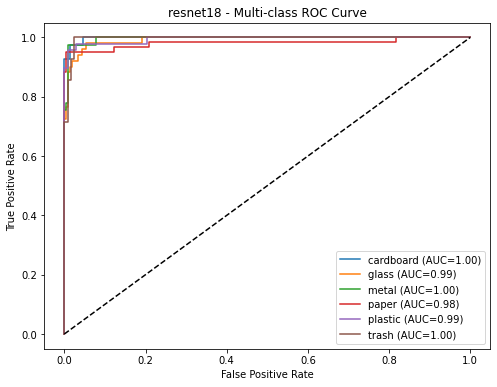


🔍 Evaluating resnet50 for ROC...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3418370374.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio

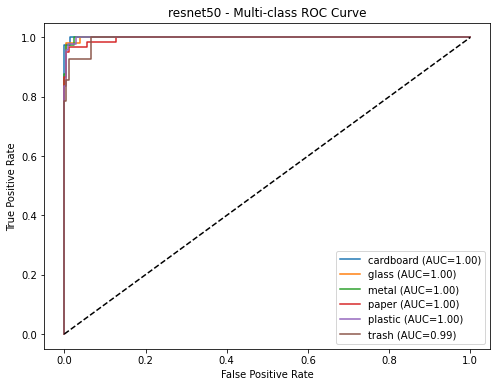


🔍 Evaluating densenet121 for ROC...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3418370374.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio

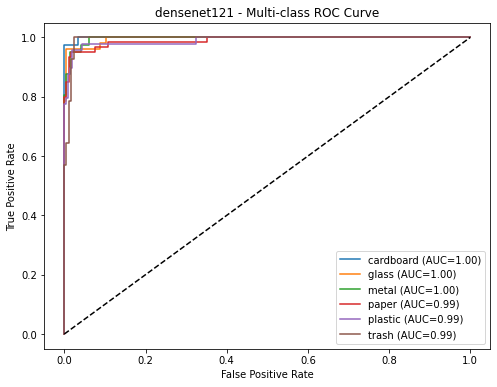


🔍 Evaluating efficientnet_b0 for ROC...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3418370374.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio

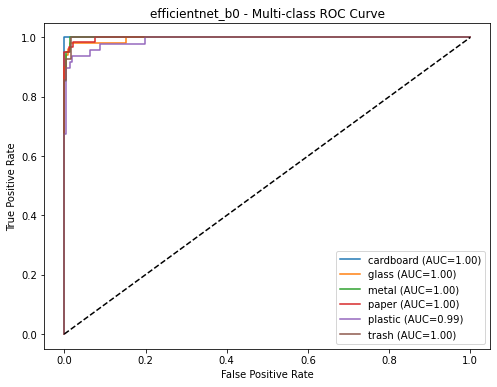


🔍 Evaluating mobilenet_v2 for ROC...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/3418370374.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio

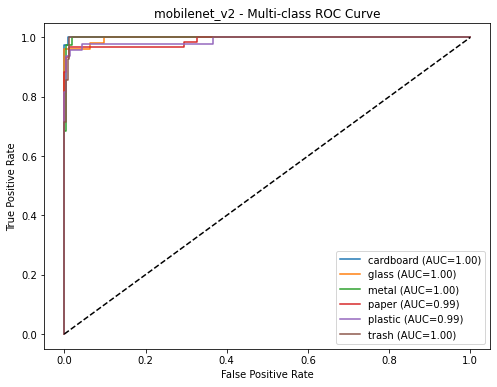

In [33]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# Model constructor
# -------------------------------
def build_model(name, num_classes):
    if name == "resnet18":
        model = models.resnet18(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "resnet50":
        model = models.resnet50(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = models.densenet121(pretrained=False)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif name == "mobilenet_v2":
        model = models.mobilenet_v2(pretrained=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model {name}")
    return model

# -------------------------------
# ROC Curve for multi-class
# -------------------------------
models_to_eval = ["resnet18", "resnet50", "densenet121", "efficientnet_b0", "mobilenet_v2"]
num_classes = len(image_datasets["train"].classes)

for mname in models_to_eval:
    print(f"\n🔍 Evaluating {mname} for ROC...")

    # Load model and weights
    model = build_model(mname, num_classes).to(device)
    state_dict = torch.load(f"{mname}_best.pth", map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    y_true, y_pred_proba = [], []

    # Collect true labels and predicted probabilities
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred_proba.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)

    # Binarize true labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))

    for i, cls in enumerate(image_datasets["train"].classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{mname} - Multi-class ROC Curve")
    plt.legend()
    plt.show()


In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# Model constructor
# -------------------------------
def build_model(name, num_classes):
    if name == "resnet18":
        model = models.resnet18(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "resnet50":
        model = models.resnet50(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = models.densenet121(pretrained=False)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif name == "mobilenet_v2":
        model = models.mobilenet_v2(pretrained=False)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model {name}")
    return model

# -------------------------------
# Evaluation loop
# -------------------------------
models_to_eval = ["resnet18", "resnet50", "densenet121", "efficientnet_b0", "mobilenet_v2"]
num_classes = len(image_datasets["train"].classes)

all_metrics = []

for mname in models_to_eval:
    print(f"\n🔍 Evaluating {mname}...")

    # Load model
    model = build_model(mname, num_classes).to(device)
    state_dict = torch.load(f"{mname}_best.pth", map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    report = classification_report(y_true, y_pred, target_names=image_datasets["train"].classes, output_dict=True)
    acc = (y_true == y_pred).mean()
    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    all_metrics.append({
        "Model": mname,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Cohen's Kappa": kappa,
        "MCC": mcc,
        "Balanced Accuracy": bal_acc
    })

# Final summary table
df_metrics = pd.DataFrame(all_metrics)
print("\n===== Model Performance Summary =====")
print(df_metrics.round(3))
df_metrics.to_csv("model_full_metrics.csv", index=False)



🔍 Evaluating resnet18...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/713625382.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function


🔍 Evaluating resnet50...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/713625382.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function


🔍 Evaluating densenet121...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/713625382.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function


🔍 Evaluating efficientnet_b0...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/713625382.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function


🔍 Evaluating mobilenet_v2...


/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_39888/713625382.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function